In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings('ignore')

In [3]:
df=pd.read_csv("insurance.csv")

In [4]:
df

,age,sex,bmi,children,smoker,region,expenses
0,19,female,27.9,0,yes,southwest,16884.92
1,18,male,33.8,1,no,southeast,1725.55
2,28,male,33.0,3,no,southeast,4449.46
3,33,male,22.7,0,no,northwest,21984.47
4,32,male,28.9,0,no,northwest,3866.86
...,...,...,...,...,...,...,...
1333,50,male,31.0,3,no,northwest,10600.55
1334,18,female,31.9,0,no,northeast,2205.98
1335,18,female,36.9,0,no,southeast,1629.83
1336,21,female,25.8,0,no,southwest,2007.95


EDA

In [5]:
df.shape

(1338, 7)

In [6]:
df.head()

,age,sex,bmi,children,smoker,region,expenses
0,19,female,27.9,0,yes,southwest,16884.92
1,18,male,33.8,1,no,southeast,1725.55
2,28,male,33.0,3,no,southeast,4449.46
3,33,male,22.7,0,no,northwest,21984.47
4,32,male,28.9,0,no,northwest,3866.86


In [7]:
df.tail()

,age,sex,bmi,children,smoker,region,expenses
1333,50,male,31.0,3,no,northwest,10600.55
1334,18,female,31.9,0,no,northeast,2205.98
1335,18,female,36.9,0,no,southeast,1629.83
1336,21,female,25.8,0,no,southwest,2007.95
1337,61,female,29.1,0,yes,northwest,29141.36


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   expenses  1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [9]:
df.describe()

,age,bmi,children,expenses
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.665471,1.094918,13270.422414
std,14.049960,6.098382,1.205493,12110.011240
min,18.000000,16.000000,0.000000,1121.870000
25%,27.000000,26.300000,0.000000,4740.287500
50%,39.000000,30.400000,1.000000,9382.030000
75%,51.000000,34.700000,2.000000,16639.915000
max,64.000000,53.100000,5.000000,63770.430000


In [10]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
expenses    0
dtype: int64

In [11]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'expenses'], dtype='object')

In [12]:
numeric_columns=['age',  'bmi', 'children',  'expenses']

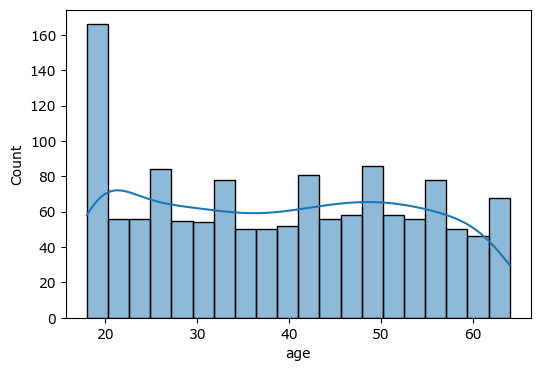

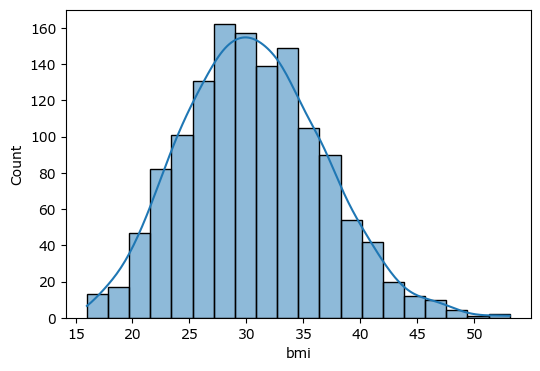

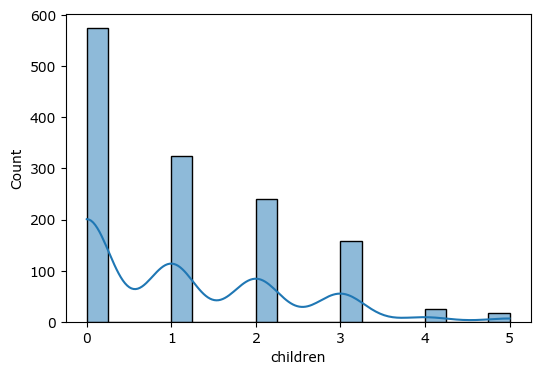

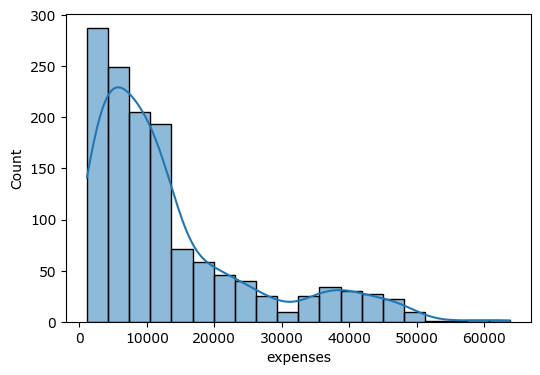

In [13]:

for col in numeric_columns:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col],kde=True,bins=20)
    

<Axes: xlabel='children', ylabel='count'>

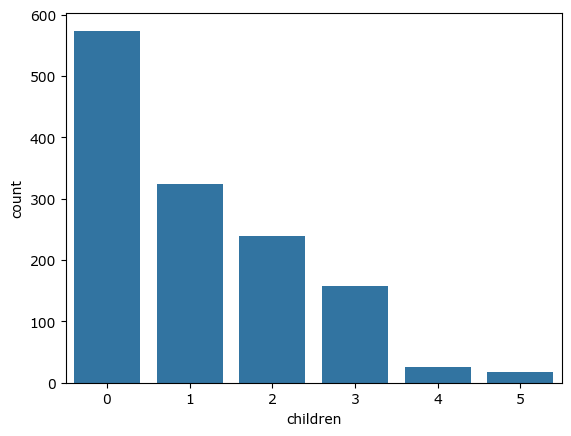

In [14]:
sns.countplot(x=df['children'])

<Axes: xlabel='sex', ylabel='count'>

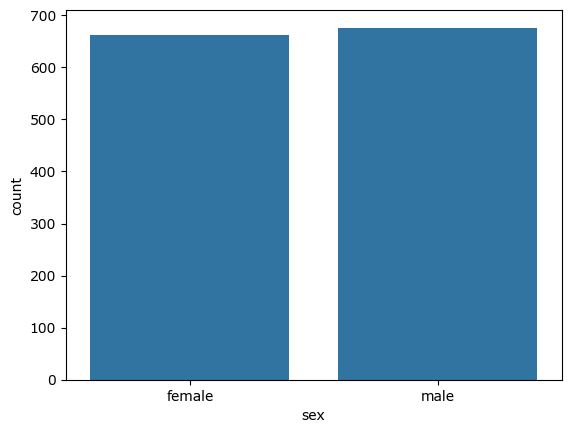

In [15]:
sns.countplot(x=df['sex'])

<Axes: xlabel='smoker', ylabel='count'>

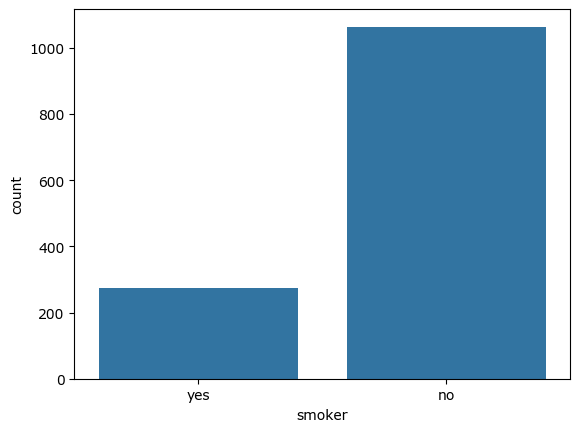

In [16]:
sns.countplot(x=df['smoker'])

<Axes: ylabel='count'>

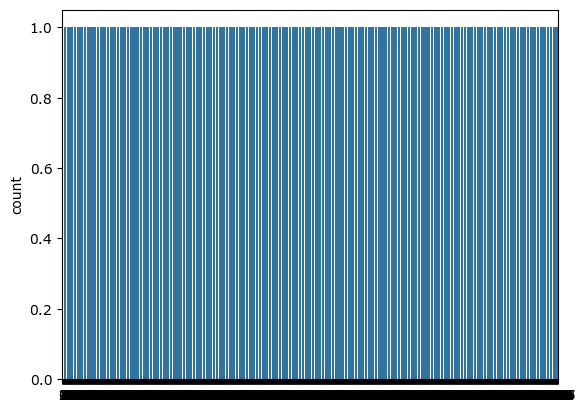

In [17]:
sns.countplot(df['expenses'])

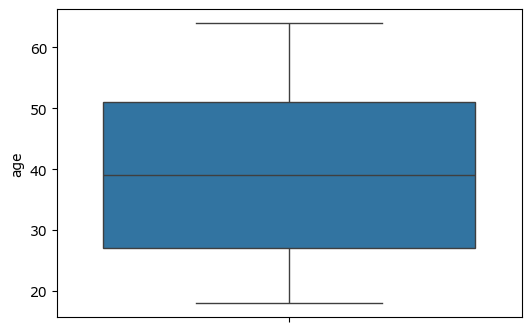

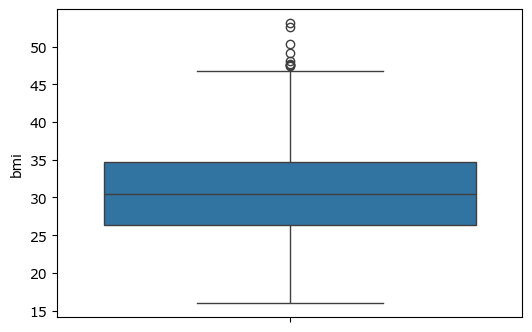

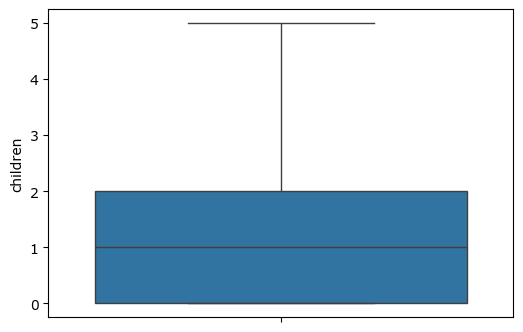

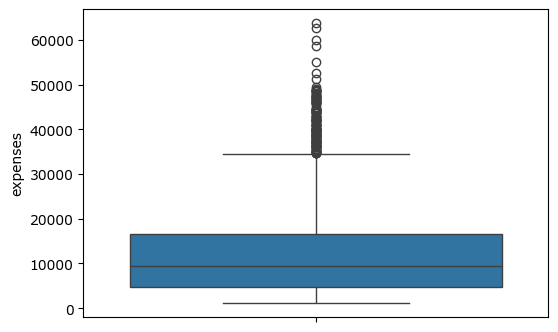

In [18]:

for col in numeric_columns:
    plt.figure(figsize=(6,4))
    sns.boxplot(df[col])

<Axes: >

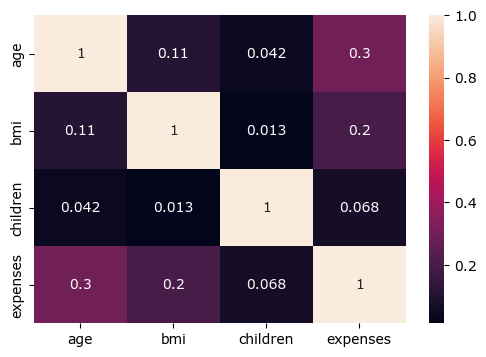

In [19]:

    plt.figure(figsize=(6,4))
    sns.heatmap(df.corr(numeric_only=True),annot=True)

Data Cleaning and preprocessing

In [20]:
df_cleanedd=df.copy()

In [21]:
df_cleanedd.head()

,age,sex,bmi,children,smoker,region,expenses
0,19,female,27.9,0,yes,southwest,16884.92
1,18,male,33.8,1,no,southeast,1725.55
2,28,male,33.0,3,no,southeast,4449.46
3,33,male,22.7,0,no,northwest,21984.47
4,32,male,28.9,0,no,northwest,3866.86


In [22]:
df_cleanedd.shape

(1338, 7)

In [23]:
df_cleanedd.drop_duplicates(inplace=True)

In [24]:
df_cleanedd.shape

(1337, 7)

In [25]:
df_cleanedd.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
expenses    0
dtype: int64

In [26]:
df_cleanedd.dtypes

age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
expenses    float64
dtype: object

In [27]:
df_cleanedd['sex'].value_counts()

sex
male      675
female    662
Name: count, dtype: int64

In [28]:
df_cleanedd['sex']=df_cleanedd['sex'].map({"female":1,"male":0})


In [29]:
df_cleanedd

,age,sex,bmi,children,smoker,region,expenses
0,19,1,27.9,0,yes,southwest,16884.92
1,18,0,33.8,1,no,southeast,1725.55
2,28,0,33.0,3,no,southeast,4449.46
3,33,0,22.7,0,no,northwest,21984.47
4,32,0,28.9,0,no,northwest,3866.86
...,...,...,...,...,...,...,...
1333,50,0,31.0,3,no,northwest,10600.55
1334,18,1,31.9,0,no,northeast,2205.98
1335,18,1,36.9,0,no,southeast,1629.83
1336,21,1,25.8,0,no,southwest,2007.95


In [30]:
df_cleanedd['smoker']=df_cleanedd['smoker'].map({"yes":1,"no":0})

In [31]:
df_cleanedd

,age,sex,bmi,children,smoker,region,expenses
0,19,1,27.9,0,1,southwest,16884.92
1,18,0,33.8,1,0,southeast,1725.55
2,28,0,33.0,3,0,southeast,4449.46
3,33,0,22.7,0,0,northwest,21984.47
4,32,0,28.9,0,0,northwest,3866.86
...,...,...,...,...,...,...,...
1333,50,0,31.0,3,0,northwest,10600.55
1334,18,1,31.9,0,0,northeast,2205.98
1335,18,1,36.9,0,0,southeast,1629.83
1336,21,1,25.8,0,0,southwest,2007.95


In [32]:
df_cleanedd.rename(columns={
    "sex":'is_female',
    "smoker":'is_smoker'
},inplace=True)

In [33]:
df_cleanedd.head()

,age,is_female,bmi,children,is_smoker,region,expenses
0,19,1,27.9,0,1,southwest,16884.92
1,18,0,33.8,1,0,southeast,1725.55
2,28,0,33.0,3,0,southeast,4449.46
3,33,0,22.7,0,0,northwest,21984.47
4,32,0,28.9,0,0,northwest,3866.86


In [34]:
df['region'].value_counts()

region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64

In [35]:
df_cleanedd=pd.get_dummies(df_cleanedd,columns=['region'],drop_first=True)

In [36]:
df_cleanedd

,age,is_female,bmi,children,is_smoker,expenses,region_northwest,region_southeast,region_southwest
0,19,1,27.9,0,1,16884.92,False,False,True
1,18,0,33.8,1,0,1725.55,False,True,False
2,28,0,33.0,3,0,4449.46,False,True,False
3,33,0,22.7,0,0,21984.47,True,False,False
4,32,0,28.9,0,0,3866.86,True,False,False
...,...,...,...,...,...,...,...,...,...
1333,50,0,31.0,3,0,10600.55,True,False,False
1334,18,1,31.9,0,0,2205.98,False,False,False
1335,18,1,36.9,0,0,1629.83,False,True,False
1336,21,1,25.8,0,0,2007.95,False,False,True


In [37]:
df_cleanedd=df_cleanedd.astype(int)

In [38]:
df_cleanedd

,age,is_female,bmi,children,is_smoker,expenses,region_northwest,region_southeast,region_southwest
0,19,1,27,0,1,16884,0,0,1
1,18,0,33,1,0,1725,0,1,0
2,28,0,33,3,0,4449,0,1,0
3,33,0,22,0,0,21984,1,0,0
4,32,0,28,0,0,3866,1,0,0
...,...,...,...,...,...,...,...,...,...
1333,50,0,31,3,0,10600,1,0,0
1334,18,1,31,0,0,2205,0,0,0
1335,18,1,36,0,0,1629,0,1,0
1336,21,1,25,0,0,2007,0,0,1


Feature Engineering and Extraction

In [39]:
df_cleanedd['bmi_category']=pd.cut(
    df_cleanedd['bmi'],
    bins=[0,18.5,24.9,29.9,float('inf')],
    labels=['Unverweight','Normal','Overwight','Obese']
)

In [40]:
df_cleanedd

,age,is_female,bmi,children,is_smoker,expenses,region_northwest,region_southeast,region_southwest,bmi_category
0,19,1,27,0,1,16884,0,0,1,Overwight
1,18,0,33,1,0,1725,0,1,0,Obese
2,28,0,33,3,0,4449,0,1,0,Obese
3,33,0,22,0,0,21984,1,0,0,Normal
4,32,0,28,0,0,3866,1,0,0,Overwight
...,...,...,...,...,...,...,...,...,...,...
1333,50,0,31,3,0,10600,1,0,0,Obese
1334,18,1,31,0,0,2205,0,0,0,Obese
1335,18,1,36,0,0,1629,0,1,0,Obese
1336,21,1,25,0,0,2007,0,0,1,Overwight


In [41]:
df_cleanedd=pd.get_dummies(df_cleanedd,columns=['bmi_category'],drop_first=True)
df_cleanedd=df_cleanedd.astype(int)
df_cleanedd.head()

,age,is_female,bmi,children,is_smoker,expenses,region_northwest,region_southeast,region_southwest,bmi_category_Normal,bmi_category_Overwight,bmi_category_Obese
0,19,1,27,0,1,16884,0,0,1,0,1,0
1,18,0,33,1,0,1725,0,1,0,0,0,1
2,28,0,33,3,0,4449,0,1,0,0,0,1
3,33,0,22,0,0,21984,1,0,0,1,0,0
4,32,0,28,0,0,3866,1,0,0,0,1,0


In [42]:
df_cleanedd.columns

Index(['age', 'is_female', 'bmi', 'children', 'is_smoker', 'expenses',
       'region_northwest', 'region_southeast', 'region_southwest',
       'bmi_category_Normal', 'bmi_category_Overwight', 'bmi_category_Obese'],
      dtype='object')

In [43]:
from sklearn.preprocessing import StandardScaler
cols=['age','bmi','children']
scaler=StandardScaler()
df_cleanedd[cols]=scaler.fit_transform(df_cleanedd[cols]) 

In [45]:
X = df_cleanedd.drop('expenses', axis=1)  # features
y = df_cleanedd['expenses']              # target

In [46]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 80% train, 20% test
    random_state=42     # reproducibility
)

In [47]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (1069, 11)
X_test shape: (268, 11)
y_train shape: (1069,)
y_test shape: (268,)


In [48]:
from sklearn.linear_model import LinearRegression

In [49]:
model=LinearRegression()
model.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [51]:
y_pred=model.predict(X_test)

In [52]:
y_pred

array([ 8036.18158766,  5211.16383724, 14552.96884471, 32459.33916036,
        8920.63611688, 13308.30587631, 30599.46821602,   807.33087406,
       11225.52860875, 10057.41324964, 10565.58822411, 32183.92864239,
       32011.34744879, 15644.02535309, 10637.83444755,  8221.31748041,
        5218.71451781, 32484.11084253,  2731.38638729,  3969.9137434 ,
        4859.97844075, 29278.10061446, 13720.30661022, 29264.32806636,
       31481.96219303,  6387.56219278, 34919.44562736, 37579.42425575,
       13025.72830497, 14654.7011368 ,  8099.73079303, 13017.47917353,
         317.38685741, 11080.65528838, 37284.24666971, 13033.85125032,
        3476.52849979,  4440.68980408, 31305.89307509,  8110.08245309,
        6411.01443177, 30634.73221451, 35360.62283149, 13580.17362108,
        7862.37884732,  2810.35177746,  5488.35936863,  7330.59181917,
        3656.44334776, 10496.54969999,  7916.64234365, 10745.3246297 ,
       30883.81561016,  4784.72338581, 11336.76363607, 11599.35667708,
      

In [55]:
from sklearn.metrics import r2_score

In [56]:
r2=r2_score(y_test,y_pred)
r2

0.8046053548530817

In [59]:
n=X_test.shape[0]
p=X_test.shape[1]
adjusted_r2=1-((1-r2)*(n-1)/(n-p-1))
adjusted_r2

0.7962094911944251

In [60]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 4311.898490363911
MSE: 35904964.67592625
RMSE: 5992.075156064571
R2 Score: 0.8046053548530817


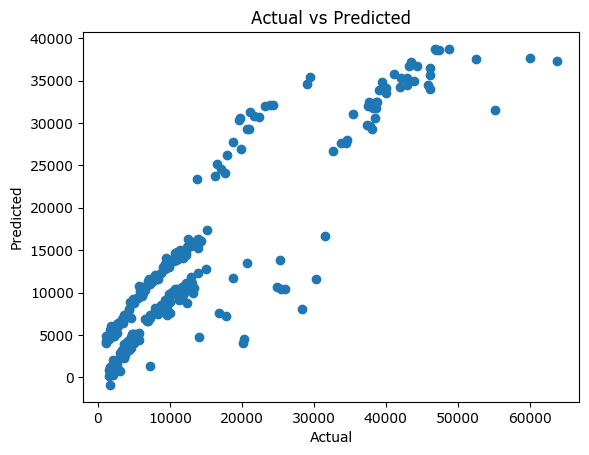

In [61]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()

In [62]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor

rf = RandomForestRegressor()
dt = DecisionTreeRegressor()

rf.fit(X_train, y_train)
dt.fit(X_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [63]:
from sklearn.model_selection import GridSearchCV

params = {
    'n_estimators': [50, 100],
    'max_depth': [None, 10, 20]
}

grid = GridSearchCV(RandomForestRegressor(), params, cv=5)
grid.fit(X_train, y_train)

print(grid.best_params_)

{'max_depth': 10, 'n_estimators': 50}


<Axes: >

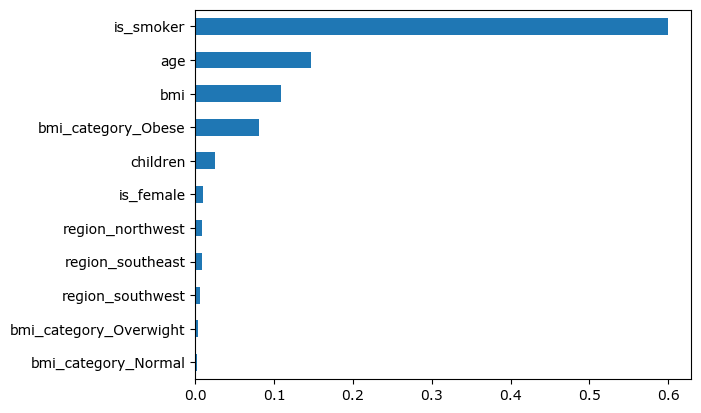

In [64]:
import pandas as pd

importance = rf.feature_importances_
feat_imp = pd.Series(importance, index=X.columns)
feat_imp.sort_values().plot(kind='barh')

In [66]:
import pickle

pickle.dump(rf, open('model.pkl', 'wb'))